In [1]:
# =============================================================================
# CELL 1: Imports
# =============================================================================
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras as K
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports loaded successfully")

Imports loaded successfully


In [2]:
# =============================================================================
# CELL 2: Load ALL Quantum Features from All Clients
# =============================================================================
BASE_PATH = "quantum_features"

all_features = []
all_labels = []

for client_id in range(1, 6):
    features_path = os.path.join(BASE_PATH, f"client_{client_id}", "train_features.npy")
    labels_path = os.path.join(BASE_PATH, f"client_{client_id}", "train_labels.npy")

    features = np.load(features_path)
    labels = np.load(labels_path)

    all_features.append(features)
    all_labels.append(labels)

    print(f"Client {client_id}: {len(features)} samples")

X_all = np.vstack(all_features)
y_all = np.concatenate(all_labels)

print(f"\nTotal combined samples: {len(X_all)}")
print(f"Feature shape: {X_all.shape}")

Client 1: 1600 samples
Client 2: 1600 samples
Client 3: 1600 samples
Client 4: 1600 samples
Client 5: 1600 samples

Total combined samples: 8000
Feature shape: (8000, 4096)


In [3]:
# =============================================================================
# CELL 3: Create Uniform IID Split AND Compute Class Weights
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=None, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

# Compute class weights (to handle any imbalance)
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\nClass weights: {class_weight_dict}")


Training samples: 6400
Test samples: 1600

Class weights: {0: 0.9962640099626401, 1: 0.9919404835709857, 2: 1.0171646535282899, 3: 0.9950248756218906}


In [4]:
# =============================================================================
# CELL 4: SANITY CHECK - RandomForest on Quantum Features
# =============================================================================
print("=" * 60)
print("SANITY CHECK: RandomForest on quantum features")
print("=" * 60)

# Use a portion for quick test
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"\nRandomForest Accuracy: {rf_acc * 100:.2f}%")
print("\nRandomForest Classification Report:")
print(classification_report(y_test, rf_pred))

if rf_acc < 0.30:
    print("\n*** WARNING: RandomForest also performs poorly! ***")
    print("This suggests the quantum features may not be distinguishable.")
else:
    print(
        f"\n*** RandomForest achieves {rf_acc * 100:.2f}% - Features ARE separable! ***"
    )


SANITY CHECK: RandomForest on quantum features

RandomForest Accuracy: 59.25%

RandomForest Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.69      0.57       394
           1       0.74      0.69      0.71       387
           2       0.73      0.56      0.63       427
           3       0.48      0.43      0.45       392

    accuracy                           0.59      1600
   macro avg       0.61      0.59      0.59      1600
weighted avg       0.61      0.59      0.59      1600


*** RandomForest achieves 59.25% - Features ARE separable! ***


In [6]:
# =============================================================================
# CELL 5: Build QCNN Model (from uniform_test.py)
# =============================================================================
INPUT_DIM = 4096
NUM_CLASSES = 4
LEARNING_RATE = 0.0001  # Lower learning rate for stability
DENSE_LAYERS = [512, 256, 128]  # Simpler architecture


def build_qcnn_model_v2():
    model = K.Sequential(
        [
            layers.Input(shape=(INPUT_DIM,)),
            layers.Flatten(),
            # First dense layer WITHOUT BatchNorm at input
            layers.Dense(DENSE_LAYERS[0], kernel_initializer="he_uniform"),
            layers.LeakyReLU(negative_slope=0.1),
            layers.BatchNormalization(),
            layers.Dropout(0.4),  # Higher dropout
            layers.Dense(DENSE_LAYERS[1], kernel_initializer="he_uniform"),
            layers.LeakyReLU(negative_slope=0.1),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(DENSE_LAYERS[2], kernel_initializer="he_uniform"),
            layers.LeakyReLU(negative_slope=0.1),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(NUM_CLASSES, activation="softmax"),
        ]
    )

    model.compile(
        optimizer=K.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = build_qcnn_model_v2()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,988 (8.64 MB)

 Trainable params: 2,264,196 (8.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
# =============================================================================
# CELL 5: Train the Model
# =============================================================================
EPOCHS = 30
BATCH_SIZE = 32

print("Training QCNN model...")
history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1,
)

print("\nTraining complete!")


Training QCNN model...
Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.3054 - loss: 1.8467 - val_accuracy: 0.4106 - val_loss: 1.3286
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4495 - loss: 1.3778 - val_accuracy: 0.4319 - val_loss: 1.3121
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4880 - loss: 1.2610 - val_accuracy: 0.4288 - val_loss: 1.3447
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.5354 - loss: 1.1274 - val_accuracy: 0.4631 - val_loss: 1.1948
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5705 - loss: 1.0399 - val_accuracy: 0.4894 - val_loss: 1.1750
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5745 - loss: 1.0305 - val_accuracy: 0.4894 - val_loss: 1.1287
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5858 - loss: 1.0039 - val_accuracy: 0.4863 - val_loss: 1.1431
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6055 - 

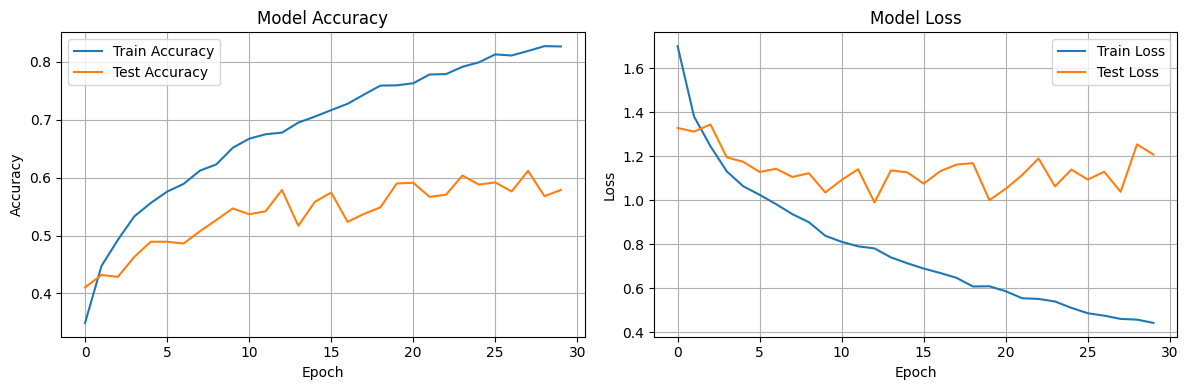

In [8]:
# =============================================================================
# CELL 6: Evaluate Model - Accuracy & Loss Curves
# =============================================================================
# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [9]:
# =============================================================================
# CELL 7: Final Evaluation - Test Set
# =============================================================================
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'=' * 50}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'=' * 50}")

# Predictions
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification Report
print("\nClassification Report:")
class_names = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Per-class accuracy
print("\nPer-class accuracy:")
for i, name in enumerate(class_names):
    mask = y_test == i
    class_acc = np.mean(y_pred_classes[mask] == i)
    print(f"  {name}: {class_acc * 100:.2f}%")


Test Accuracy: 57.88%
Test Loss: 1.2081

Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.57      0.59      0.58       394
ModerateDemented       0.82      0.69      0.75       387
     NonDemented       0.76      0.38      0.51       427
VeryMildDemented       0.40      0.67      0.50       392

        accuracy                           0.58      1600
       macro avg       0.64      0.58      0.59      1600
    weighted avg       0.64      0.58      0.58      1600


Per-class accuracy:
  MildDemented: 59.39%
  ModerateDemented: 68.99%
  NonDemented: 38.41%
  VeryMildDemented: 66.58%


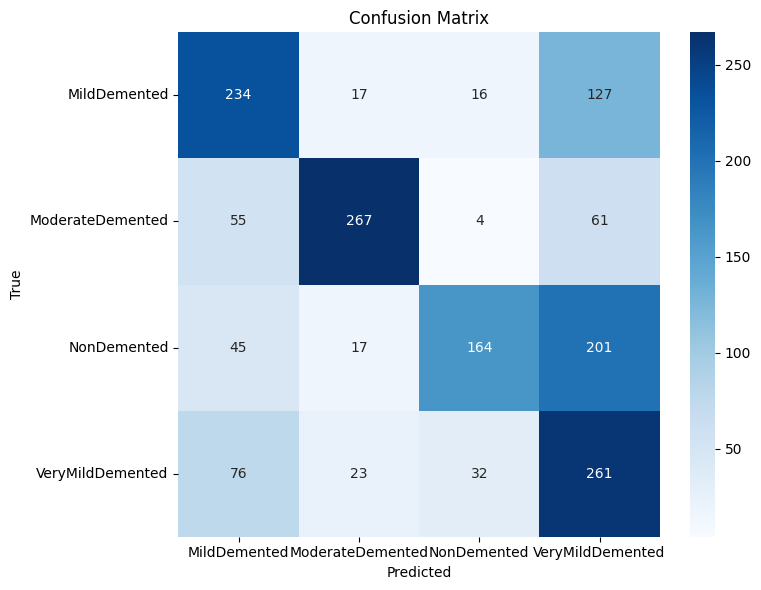

In [10]:

# =============================================================================
# CELL 8: Confusion Matrix
# =============================================================================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [11]:

# =============================================================================
# CELL 9: Also Test on Global Test Set (if exists)
# =============================================================================
global_test_features_path = os.path.join(BASE_PATH, "global_test_features.npy")
global_test_labels_path = os.path.join(BASE_PATH, "global_test_labels.npy")

if os.path.exists(global_test_features_path) and os.path.exists(
    global_test_labels_path
):
    X_global_test = np.load(global_test_features_path)
    y_global_test = np.load(global_test_labels_path)

    print(f"\nGlobal test set: {len(X_global_test)} samples")

    # Evaluate
    global_loss, global_acc = model.evaluate(X_global_test, y_global_test, verbose=0)
    print(f"\n{'=' * 50}")
    print(f"Global Test Accuracy: {global_acc * 100:.2f}%")
    print(f"Global Test Loss: {global_loss:.4f}")
    print(f"{'=' * 50}")

    # Predictions
    y_global_pred = model.predict(X_global_test, verbose=0)
    y_global_pred_classes = np.argmax(y_global_pred, axis=1)

    print("\nClassification Report (Global Test):")
    print(
        classification_report(
            y_global_test, y_global_pred_classes, target_names=class_names
        )
    )
else:
    print("\nGlobal test set not found. Skipping.")



Global test set: 2000 samples

Global Test Accuracy: 61.55%
Global Test Loss: 1.0822

Classification Report (Global Test):
                  precision    recall  f1-score   support

    MildDemented       0.61      0.63      0.62       500
ModerateDemented       0.82      0.69      0.75       500
     NonDemented       0.83      0.38      0.52       500
VeryMildDemented       0.46      0.76      0.57       500

        accuracy                           0.62      2000
       macro avg       0.68      0.62      0.62      2000
    weighted avg       0.68      0.62      0.62      2000

